# Custom SINDy Test
Using a custom implementation of SINDy (Sparse Identification of Nonlinear Dynamics), fit models to cardiac data generated from the  FitzHugh-Nagumo (FHN) equations.

In [1]:
import numpy as np
from scipy.integrate import odeint
from sklearn import metrics
from sklearn.linear_model import Lasso
from itertools import combinations_with_replacement
import matplotlib.pyplot as plt
import pandas as pd
import importlib
import SINDy
importlib.reload(SINDy)

import pysindy as ps

# FHN system definition
def fhn(state, t, alpha = 0.1, beta = 1, gamma = 1.6, delta = 0.1, eps = 0.01):
    u, v = state
    u_dot = u*(1-u)*(u-alpha) - v   # Note - The cardiac version without hyperpolarization (FHN-c) has -u*v instead of -v. ID success can change depending on which variant we use.
    v_dot = eps*(beta*u - gamma*v - delta)
    return u_dot, v_dot

# FHN-c (cardiac variant of FHN) system definition
def fhn_c(state, t, alpha = 0.1, beta = 1, gamma = 1.6, delta = 0.1, eps = 0.01):
    u, v = state
    u_dot = u*(1-u)*(u-alpha) - u*v   # Note - The cardiac version without hyperpolarization (FHN-c) has -u*v instead of -v. ID success can change depending on which variant we use.
    v_dot = eps*(beta*u - gamma*v - delta)
    return u_dot, v_dot

# Calculate derivative given either of the above FHN definitions
def fhn_derivative(states, fhn, dt=1):
    u_dot, v_dot = fhn(states[0, :], dt)
    dx_dt = np.array((u_dot, v_dot))
    for i in range(1, states.shape[0]):
        u_dot, v_dot = fhn(states[i, :], dt)
        dx_dt = np.vstack((dx_dt, np.array((u_dot, v_dot))))
    return dx_dt

In [2]:
# Time step and initial values
dt = 0.01
t = np.arange(0,400,dt)
x_0 = np.array([0.5,0])

states = odeint(fhn, x_0, t)
dx_dt = fhn_derivative(states, fhn, dt)
states_c = odeint(fhn_c, x_0, t)
dx_dt_c = fhn_derivative(states_c, fhn, dt)

df_states = pd.DataFrame(states, columns=['u','v'])
df_dxdt = pd.DataFrame(dx_dt, columns=['u','v'])

df_states_c = pd.DataFrame(states_c, columns=['u','v'])
df_dxdt_c = pd.DataFrame(dx_dt_c, columns=['u','v'])

Text(0.5, 1.0, 'Values of u vs. v (FHN)')

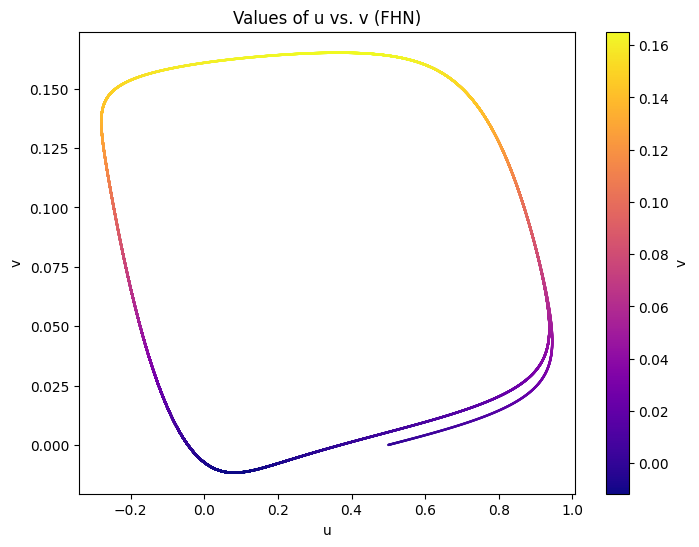

In [3]:
# Plot the matrix of states and dx_dt             
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_states['u'], 
    df_states['v'], 
    c=df_states['v'],  # Color shade controlled by v column
    s=0.5,  # Marker size
    cmap='plasma'
)

# Add colorbar for the v values
plt.colorbar(scatter, label='v')
plt.xlabel('u')
plt.ylabel('v')
plt.title('Values of u vs. v (FHN)')

Text(0.5, 1.0, "Values of u' vs. v' (FHN)")

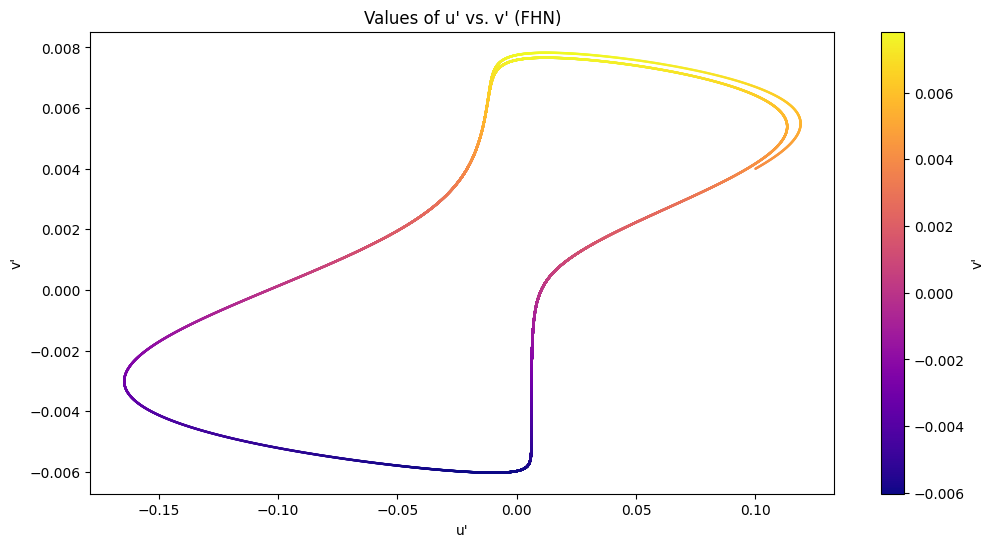

In [4]:
plt.figure(figsize=(12, 6))
scatter = plt.scatter(
    df_dxdt['u'], 
    df_dxdt['v'], 
    c=df_dxdt['v'],  # Color shade controlled by v column
    s=0.5,  # Marker size
    cmap='plasma'
)

# Add colorbar for the v values
plt.colorbar(scatter, label='v\'')
plt.xlabel('u\'')
plt.ylabel('v\'')
plt.title('Values of u\' vs. v\' (FHN)')

In [5]:
# Run SINDy and get the output equations
sindy = SINDy.SINDy(feature_names='uv')
sindy.fit(states, dx_dt)
sindy.equations()

(40000, 2)
(40000, 10)
(10, 2)
Functions:
 ['1' 'u' 'v' 'uu' 'uv' 'vv' 'uuu' 'uuv' 'uvv' 'vvv']

Fit coefficients (Xi):
 [[ 0.   0. ]
 [-0.1  0. ]
 [-1.   0. ]
 [ 1.1  0. ]
 [ 0.   0. ]
 [ 0.   0. ]
 [-1.   0. ]
 [ 0.   0. ]
 [ 0.   0. ]
 [ 0.   0. ]]


["u' = -0.100u + -1.000v + 1.1000uu + -1.000uuu", "v' = "]

[0.5, 0.5010010488594147, 0.5020041940156946, 0.5030094317566455, 0.5040167576225368, 0.5050261686473728, 0.506037659847494, 0.5070512266085605, 0.5080668643162324, 0.5090845683561694]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


(0.0, 400.0)

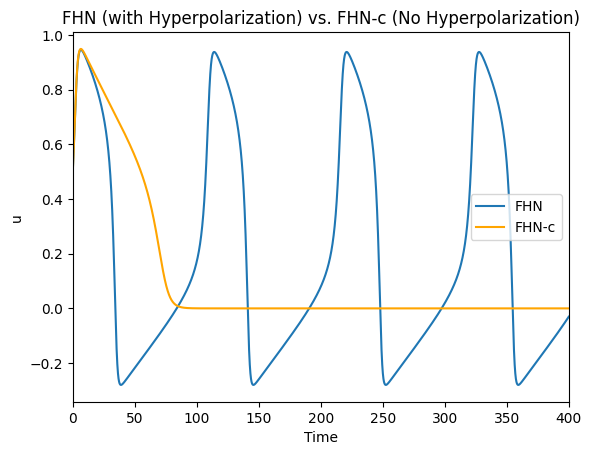

In [6]:
# Plot u vs. t in order to visualize action potential. Compare FHN and FHN-c on the same plot.
u = df_states['u'].tolist()
u_c = df_states_c['u'].tolist()
print(u[0:10])
print(t[0:10])

plt.plot(t,u, label='FHN')
plt.plot(t,u_c, color='orange', label='FHN-c')
plt.title('FHN (with Hyperpolarization) vs. FHN-c (No Hyperpolarization)')
plt.xlabel('Time')
plt.ylabel('u')
plt.legend()
plt.xlim(0, 400)

# PySINDy Test
Try to fit data using the PySINDy Library. Also try playing around with the optimizer and feature library.

In [7]:
print(t[0:10])
print(x_0[0:10])
print(states[0:10])
print(dx_dt[0:10])

[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]
[0.5 0. ]
[[5.00000000e-01 0.00000000e+00]
 [5.01001049e-01 4.00468594e-05]
 [5.02004194e-01 8.01875099e-05]
 [5.03009432e-01 1.20422138e-04]
 [5.04016758e-01 1.60750960e-04]
 [5.05026169e-01 2.01174093e-04]
 [5.06037660e-01 2.41691762e-04]
 [5.07051227e-01 2.82304181e-04]
 [5.08066864e-01 3.23011564e-04]
 [5.09084568e-01 3.63814123e-04]]
[[0.1        0.004     ]
 [0.10020981 0.00400937]
 [0.10041925 0.00401876]
 [0.10062829 0.00402817]
 [0.10083692 0.0040376 ]
 [0.10104514 0.00404704]
 [0.10125292 0.00405651]
 [0.10146026 0.004066  ]
 [0.10166715 0.0040755 ]
 [0.10187357 0.00408502]]


In [8]:
# W/ the feature library restricted to polynomials of degree 3, the optimizer is able to identify the correct equations.
opt = ps.STLSQ(threshold=0.1)
model = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt)
model.fit(states, t=t)
model.print()

(u)' = -0.116 v + 0.872 u^2 + -5.203 v^2 + -0.917 u^3
(v)' = 0.000


c:\Anaconda\envs\sindy\lib\site-packages\pysindy\optimizers\stlsq.py:201: UserWarning: Sparsity parameter is too big (0.1) and eliminated all coefficients
  warnings.warn(


In [9]:
opt2 = ps.STLSQ(threshold=0.01)
model = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt2)
model.fit(states, t=t)
model.print()

(u)' = -0.100 u + -1.000 v + 1.100 u^2 + -1.000 u^3
(v)' = 0.000


c:\Anaconda\envs\sindy\lib\site-packages\pysindy\optimizers\stlsq.py:201: UserWarning: Sparsity parameter is too big (0.01) and eliminated all coefficients
  warnings.warn(


In [ ]:
%%capture --no-display

# Compare the optimizers over a range of threshold values. It seems like SSR is the best-performing optimizer.
# STLSQ is the default optimizer for PySINDy, but it seems to perform poorly for this system.
mse_LASSO = []
mse_STLSQ = []
mse_SR3 = []
mse_SSR = []

mse_STLSQ_norm = []
mse_SR3_norm = []
mse_SSR_norm = []

thresholds = np.arange(0.00001, 0.02, 0.001)

for thresh in thresholds:
    opt1 = Lasso(alpha=thresh, max_iter=10000, fit_intercept=False)
    opt2 = ps.STLSQ(threshold=thresh, normalize_columns=False)
    opt3 = ps.SR3(threshold=thresh, nu=1, normalize_columns=False)
    opt4 = ps.SSR(alpha=thresh, normalize_columns=False)

    opt2_norm = ps.STLSQ(threshold=thresh, normalize_columns=True)
    opt3_norm = ps.SR3(threshold=thresh, nu=1, normalize_columns=True)
    opt4_norm = ps.SSR(alpha=thresh, normalize_columns=True)


    # Fit models and calculate MSE for each optimizer without normalizing the columns.
    model1 = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt1)
    model1.fit(states, t=t)
    mse_LASSO.append(model1.score(x=states, t=t, metric=metrics.mean_squared_error))

    model2 = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt2)
    model2.fit(states, t=t)
    mse_STLSQ.append(model2.score(x=states, t=t, metric=metrics.mean_squared_error))

    model3 = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt3)
    model3.fit(states, t=t)
    mse_SR3.append(model3.score(x=states, t=t, metric=metrics.mean_squared_error))

    model4 = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt4)
    model4.fit(states, t=t)
    mse_SSR.append(model4.score(x=states, t=t, metric=metrics.mean_squared_error))


    # Fit models and calculate MSE for each optimizer and normalize the columns.
    model2_norm = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt2_norm)
    model2_norm.fit(states, t=t)
    mse_STLSQ_norm.append(model2_norm.score(x=states, t=t, metric=metrics.mean_squared_error))

    model3_norm = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt3_norm)
    model3_norm.fit(states, t=t)
    mse_SR3_norm.append(model3_norm.score(x=states, t=t, metric=metrics.mean_squared_error))

    model4_norm = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt4_norm)
    model4_norm.fit(states, t=t)
    mse_SSR_norm.append(model4_norm.score(x=states, t=t, metric=metrics.mean_squared_error))

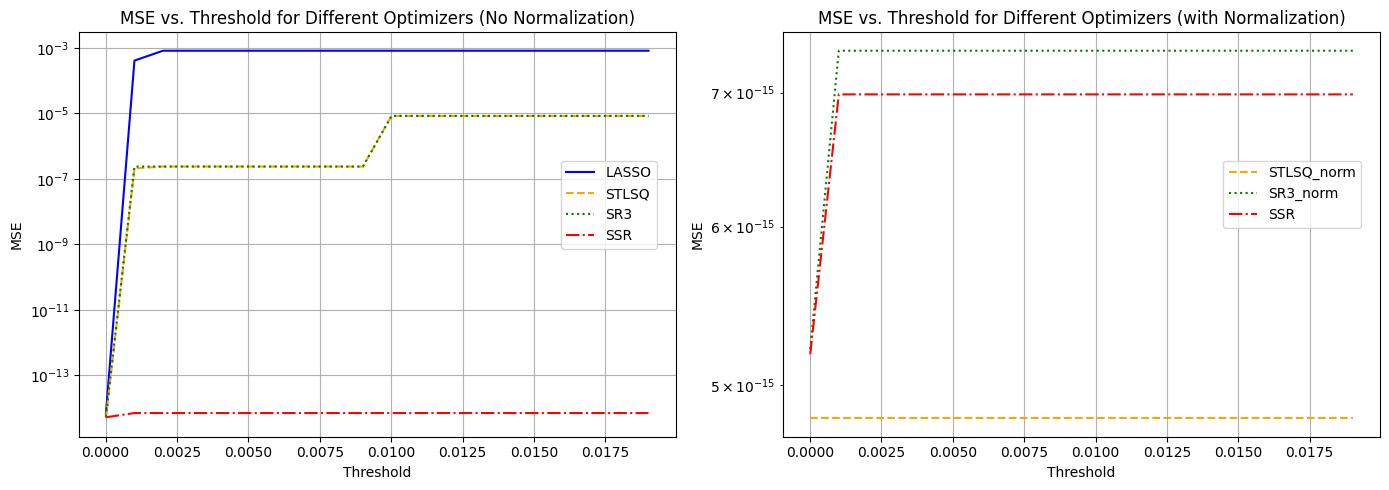

In [43]:
# Create two subplots: (left) MSE without normalization, (right) MSE with normalization.
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot the MSE errors (without normalization).
ax[0].plot(thresholds, mse_LASSO, linestyle='-', color='blue', label='LASSO')
ax[0].plot(thresholds, mse_STLSQ, linestyle='--', color='orange', label='STLSQ')
ax[0].plot(thresholds, mse_SR3, linestyle=':', color='green', label='SR3')
ax[0].plot(thresholds, mse_SSR, linestyle='-.', color='red', label='SSR')
ax[0].set_title('MSE vs. Threshold for Different Optimizers (No Normalization)')
ax[0].set_xlabel('Threshold')
ax[0].set_ylabel('MSE')
ax[0].set_yscale('log')
ax[0].grid()
ax[0].legend(loc='upper right', bbox_to_anchor=(0.98, 0.7))

# Plot the MSE errors (with normalization).
# Plot the MSE errors (with normalization).
ax[1].plot(thresholds, mse_STLSQ_norm, linestyle='--', color='orange', label='STLSQ_norm')
ax[1].plot(thresholds, mse_SR3_norm, linestyle=':', color='green', label='SR3_norm')
ax[1].plot(thresholds, mse_SSR, linestyle='-.', color='red', label='SSR')
ax[1].set_title('MSE vs. Threshold for Different Optimizers (with Normalization)')
ax[1].set_xlabel('Threshold')
ax[1].set_ylabel('MSE')
ax[1].set_yscale('log')
ax[1].grid()
ax[1].legend(loc='upper right', bbox_to_anchor=(0.98, 0.7))

fig.tight_layout()

In [44]:
# W/out a restricted feature library, the optimizer can't quite identify the correct equations, even on the best optimizer.
model = ps.SINDy(feature_names=["u", "v"], optimizer=ps.SSR(alpha=0.5))
model.fit(states, t=t)
model.print()

(u)' = 0.014 1 + 0.094 u + 0.581 v + -0.065 u^2 + -0.464 u v + -6.366 v^2
(v)' = -0.001 1 + 0.010 u + -0.016 v


# Running SINDy on Velasco-Fenton Modification of FHN
### a.) System 2.4a
This simpler of two modified forms of the FitzHugh-Nagumo equations incorporates two features that improve its ability to replicate real experimental cardiac data:
1) Hyperpolarization correction - a $uv$ term is substituted for $u$ (from Rogers and McCulloch)
2) Alternans correction - the $\dot{v}$ equation is modified to a quadratic in u in order to support sustained alternans (see Gani and Ogawa)

Here are the new equations after making these modifications:

\begin{align}
    \dot{u} = \mu u(1-u)(u-\alpha) - uv \\
    \dot{v} = \epsilon \big[ u(\beta - u) - v \big] \\
\end{align}

In [45]:
# Define the simpler form of VF-FHN
def fhn_vf(state, t, mu = 1.0, alpha = 0.2, beta = 1.08, eps = 0.005):
    u, v = state
    u_dot = mu*u*(1 - u)*(u - alpha) - u*v  # Note - The cardiac version without hyperpolarization (FHN-c) has -u*v instead of -v. ID success can change depending on which variant we use.
    v_dot = eps*(u*(beta - u) - v)
    return u_dot, v_dot

def fhn_vf_derivative(states, fhn, dt=1):
    u_dot, v_dot = fhn(states[0, :], dt)
    dx_dt = np.array((u_dot, v_dot))
    for i in range(1, states.shape[0]):
        u_dot, v_dot = fhn(states[i, :], dt)
        dx_dt = np.vstack((dx_dt, np.array((u_dot, v_dot))))
    return dx_dt

In [46]:
# Time step and initial values
t_vf = np.arange(0,1200,dt)
x_0_vf = np.array([0.5,0])
states_vf = odeint(fhn_vf, x_0_vf, t_vf)

Text(0.5, 1.0, 'Values of u vs. v (VF-FHN-a)')

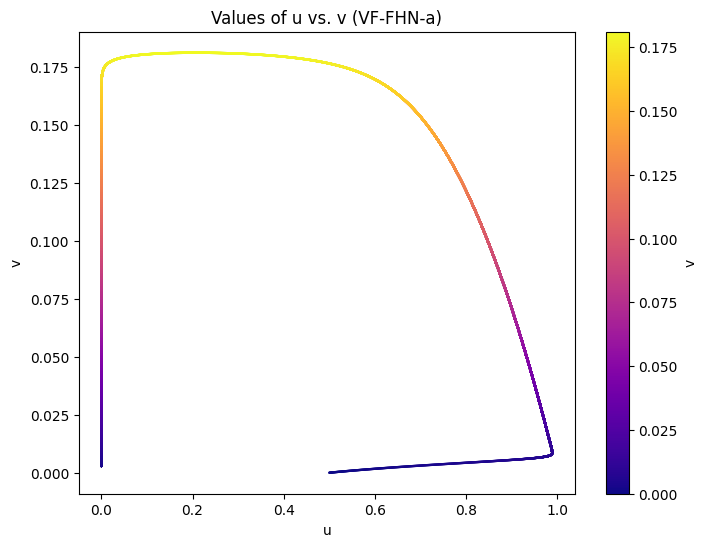

In [47]:
# Plot the vf_fhn data
df_states_vf = pd.DataFrame(states_vf, columns=['u','v'])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_states_vf['u'], 
    df_states_vf['v'], 
    c=df_states_vf['v'],  # Color shade controlled by v column
    s=0.5,  # Marker size
    cmap='plasma'
)

# Add colorbar for the v values
plt.colorbar(scatter, label='v')
plt.xlabel('u')
plt.ylabel('v')
plt.title('Values of u vs. v (VF-FHN-a)')

[0.5, 0.5007509015195563, 0.5015036063907933, 0.5022581154167702, 0.5030144294488954, 0.5037725486708812, 0.5045324738121796, 0.5052942056254505, 0.5060577448633536, 0.5068230922785487]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


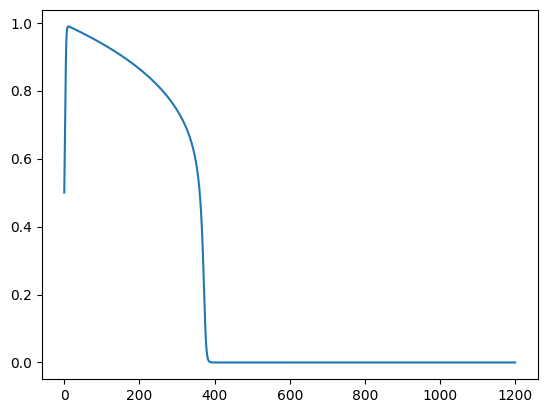

In [48]:
# Time domain - u vs. t
u_vf = df_states_vf['u'].tolist()
print(u_vf[0:10])
print(t_vf[0:10])

plt.plot(t_vf,u_vf)

In [49]:
# Run SINDy on VF-FHN
opt_vf = ps.SSR(alpha=0.5)
model_vf = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_vf)
model_vf.fit(states_vf, t=t_vf)
model_vf.print(precision=5)

(u)' = -0.20000 u + 1.20000 u^2 + -1.00000 u v + -1.00000 u^3
(v)' = 0.00540 u + -0.00500 v + -0.00500 u^2


Actual equations for comparison:

\begin{align}
    \dot{u} = - 0.2 u + 1.2 u^2 - u v - 1 u^3 \\
    \dot{v} = 0.0054 u - 0.005 v - 0.005 u^2 \\
\end{align}

### b.) System 2.4b
Let's try fitting the more complex version of the VF-FHN equations, which are as follows:

\begin{align}
    \dot{u} = \mu u(1-u)(u-\alpha) - uv \\
    \dot{v} = \epsilon \big[ (\beta - u)(u - \gamma) - \delta v - \theta \big] \\
\end{align}

In [50]:
# Define the more detailed form of VF-FHN
def fhn_vf_b(state, t, mu = 1.0, alpha = 0.2, beta = 1.1, gamma = 0.31, theta = -0.05, delta = 1, eps = 0.005):
    u, v = state
    u_dot = mu*u*(1 - u)*(u - alpha) - u*v  # Note - The cardiac version without hyperpolarization (FHN-c) has -u*v instead of -v. ID success can change depending on which variant we use.
    v_dot = eps*((beta - u)*(u - gamma) - delta*v - theta)
    return u_dot, v_dot

def fhn_vf_b_derivative(states, fhn, dt=1):
    u_dot, v_dot = fhn(states[0, :], dt)
    dx_dt = np.array((u_dot, v_dot))
    for i in range(1, states.shape[0]):
        u_dot, v_dot = fhn(states[i, :], dt)
        dx_dt = np.vstack((dx_dt, np.array((u_dot, v_dot))))
    return dx_dt

In [51]:
# Time step and initial values
t_vf_b = np.arange(0,1200,dt)
x_0_vf_b = np.array([0.5,0])
states_vf_b = odeint(fhn_vf_b, x_0_vf_b, t_vf_b)

Text(0.5, 1.0, 'Values of u vs. v (VF-FHN-b)')

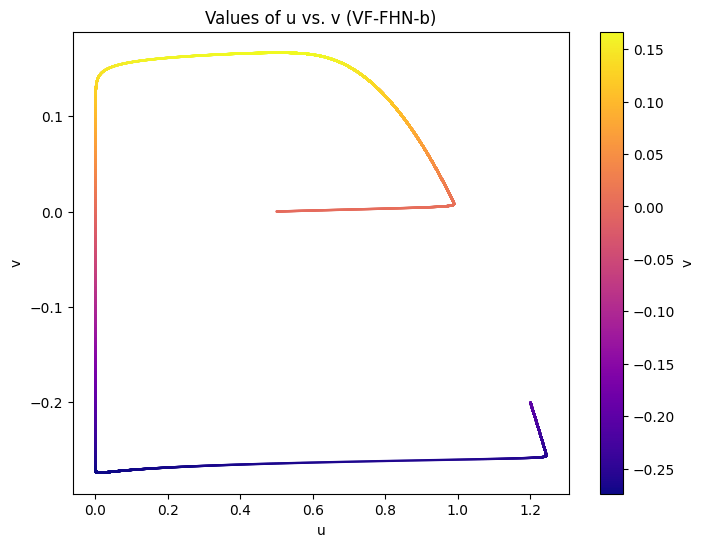

In [52]:
# Plot the vf_fhn data
df_states_vf_b = pd.DataFrame(states_vf_b, columns=['u','v'])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_states_vf_b['u'], 
    df_states_vf_b['v'], 
    c=df_states_vf_b['v'],  # Color shade controlled by v column
    s=0.5,  # Marker size
    cmap='plasma'
)

# Add colorbar for the v values
plt.colorbar(scatter, label='v')
plt.xlabel('u')
plt.ylabel('v')
plt.title('Values of u vs. v (VF-FHN-b)')

[0.5, 0.500750917303038, 0.5015036695653069, 0.5022582576951738, 0.503014682665211, 0.5037729447240928, 0.5045330447256908, 0.5052949835405066, 0.5060587620390423, 0.5068243810917998]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


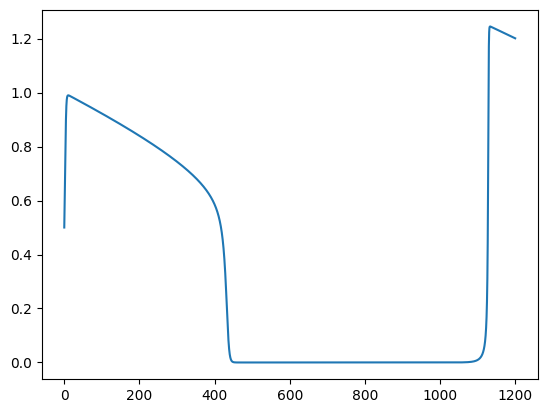

In [53]:
# Time domain - u vs. t
u_vf_b = df_states_vf_b['u'].tolist()
print(u_vf_b[0:10])
print(t_vf_b[0:10])

plt.plot(t_vf_b,u_vf_b)

In [56]:
# Run SINDy on VF-FHN
opt_vf_b = ps.SSR(alpha=0.5)
model_vf_b = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_vf_b)
model_vf_b.fit(states_vf_b, t=t_vf_b)
model_vf_b.print(precision=5)

(u)' = -0.20000 u + 1.19999 u^2 + -1.00000 u v + -0.99999 u^3
(v)' = -0.00145 1 + 0.00705 u + -0.00500 v + -0.00500 u^2


Actual equations for comparison:

\begin{align}
    \dot{u} = - 0.2 u + 1.2 u^2 - u v - 1 u^3 \\
    \dot{v} = -0.001455 + 0.00705u - 0.005u^2 - 0.005v \\
\end{align}

These have only minor discrepancies in the first two terms on the RHS of the $\dot{v}$ equation, so it seems like SINDy can still capture the dynamics of this slightly more complex model over a fairly small timeframe.